In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from typing import Tuple, Optional
import plotly.express as px
import plotly.graph_objects as go
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
# Get data into dataframe
df = pd.read_csv('../../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to only have temperature, salinity and dissolved oxygen
df_all = df.copy()
df_all = df_all[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]']]
df_ST = df_all[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']]

In [3]:
# Define random seed for reproducibility
seed = 22

In [4]:
# Scale data
scaler = StandardScaler()
df_ST_scaled = scaler.fit_transform(df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']])

In [5]:
# Extract values into a tensor
X = torch.tensor(df_ST_scaled, dtype=torch.float32)
dataset = TensorDataset(X)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [6]:
# Define Variational Autoencoder

class VAE(nn.Module):
    def __init__(self, input_dim=3, latent_dim=2):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, 16)
        self.fc3 = nn.Linear(16, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return self.fc3(h)     # no sigmoid for real-valued data

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [7]:
# Define loss function (mse and KL divergence)
def vae_loss(recon_x, x, mu, logvar):
    mse = F.mse_loss(recon_x, x, reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return mse + kld

In [8]:
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"
model = VAE(input_dim=2, latent_dim=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 50
patience = 5
best_loss = float("inf")
patience_counter = 0
best_model_state = None

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for batch in loader:
        x = batch[0].to(device)
        optimizer.zero_grad()

        recon, mu, logvar = model(x)
        loss = vae_loss(recon, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataset)
    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f}")

    # ---- Early stopping logic ----
    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(model.state_dict())
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

Epoch 1 | Loss: 1.2161
Epoch 2 | Loss: 1.2103
Epoch 3 | Loss: 1.2094
Epoch 4 | Loss: 1.2087
Epoch 5 | Loss: 1.2091
Epoch 6 | Loss: 1.2088
Epoch 7 | Loss: 1.2092
Epoch 8 | Loss: 1.2088
Epoch 9 | Loss: 1.2084
Epoch 10 | Loss: 1.2083
Epoch 11 | Loss: 1.2090
Epoch 12 | Loss: 1.2086
Epoch 13 | Loss: 1.2085
Epoch 14 | Loss: 1.2087
Epoch 15 | Loss: 1.2086
Early stopping triggered at epoch 15


In [9]:
model.eval()
with torch.no_grad():
    mu, logvar = model.encode(X.to(device))
    z = mu.cpu()   # latent representation

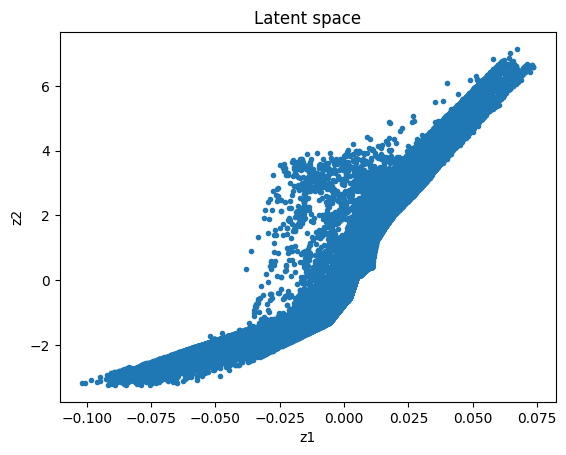

In [10]:
plt.scatter(z[:,0].cpu().tolist(), z[:,1].cpu().tolist(), marker='.')
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent space")
plt.show()

In [11]:
# Do BIC and AIC calculation for different number of clusters
bic_scores = []
n_components_range = range(1, 12)
for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed)
    gmm.fit(z.cpu().numpy())
    bic_scores.append(gmm.bic(z.cpu().numpy()))

/Users/franciscagomes/PhD/WM_class/.venv/lib/python3.12/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


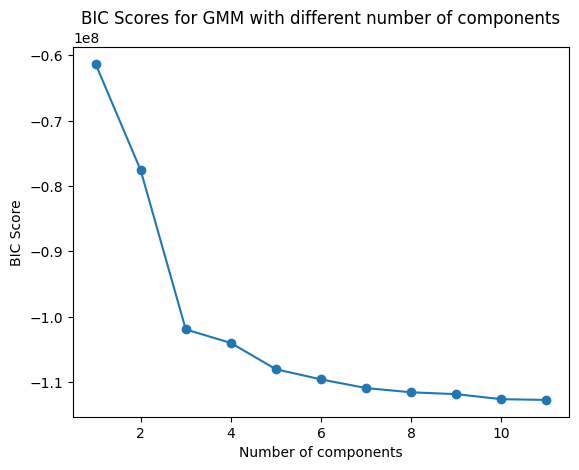

In [12]:
# BIC score plot
plt.plot(n_components_range, bic_scores, marker='o')
plt.xlabel("Number of components")  
plt.ylabel("BIC Score")
plt.title("BIC Scores for GMM with different number of components")
plt.show()

In [13]:
with torch.no_grad():
    recon = model(X.to(device))[0].cpu().numpy()

In [14]:
optimal_n_components = 3

In [15]:
gmm = GaussianMixture(n_components=optimal_n_components, random_state=seed)
gmm.fit(z)
gmm_labels = gmm.predict(z)
df_all['gmm_label'] = gmm_labels.astype(int)

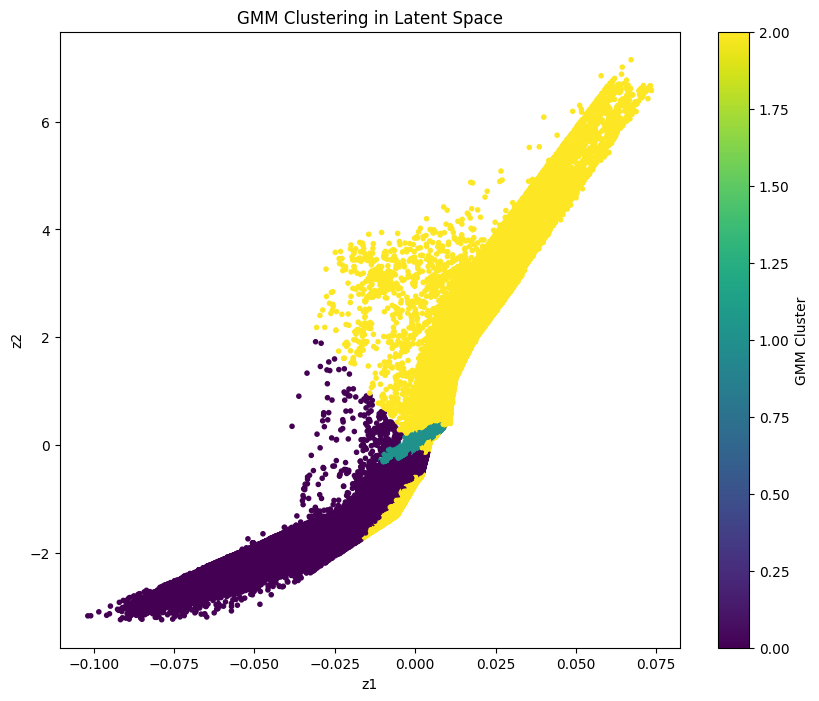

In [16]:
# Plot GMM on latent space with probability contours for each cluster
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
scatter = ax.scatter(z[:,0].cpu().tolist(), z[:,1].cpu().tolist(), c=gmm_labels, cmap='viridis', marker='.')
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("GMM Clustering in Latent Space")
plt.colorbar(scatter, label='GMM Cluster')
plt.show()

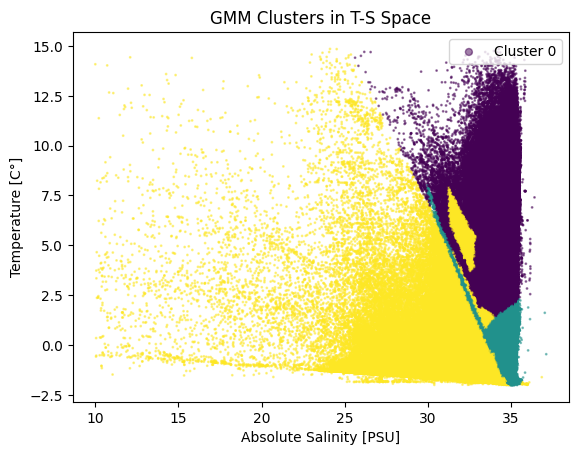

In [17]:
plt.scatter(df_ST['Absolute_Salinity_[PSU]'], df_ST['Conservative_Temperature_[deg_C]'], c=df_all['gmm_label'], s=1, alpha=0.5)
plt.xlabel("Absolute Salinity [PSU]")
plt.ylabel("Temperature [C°]")
plt.title("GMM Clusters in T-S Space")
plt.legend(loc='upper right', labels=[f'Cluster {i}' for i in range(optimal_n_components)], markerscale=5)
plt.show()

In [18]:
# # Temperature salinity diagram colored by GMM labels
# fig5 = px.scatter(
#     df_all,
#     x='Absolute_Salinity_[PSU]',
#     y='Conservative_Temperature_[deg_C]',
#     color='gmm_label',
    
#     title="Temperature-Salinity Diagram colored by GMM clusters"
# )
# fig5.update_layout(height=600, width=800)
# fig5.show()

In [19]:
# # Compute data centroid (mean location)
# center_lat = df_all['Latitude_[deg_N]'].mean()
# center_lon = df_all['Longitude_[deg_E]'].mean()

# print("Center lat:", center_lat, "Center lon:", center_lon)

# # Use labels from kmeans clustering on data to plot geographically
# fig3 = px.scatter_geo(
#     df_all,
#     lat='Latitude_[deg_N]',
#     lon='Longitude_[deg_E]',
#     color='gmm_label',
#     title="Gaussian Mixture Model on VAE latent space projected on geographic map"
# )

# fig3.update_geos(
#     projection_type="orthographic",
#     projection_rotation=dict(lat=center_lat, lon=center_lon),
#     showcoastlines=True,
#     showcountries=True
# )

# fig3.update_layout(height=800, width=800)
# fig3.show()

In [20]:
# # Plot in 3D
# fig_3d = px.scatter_3d(
#     df_all,
#     x='Latitude_[deg_N]',
#     y='Longitude_[deg_E]',
#     z='Depth_[m]',
#     color='gmm_label',
#     title="Gaussian Mixture Model clusters on Lat Lon Depth"
# )
# fig_3d.update_layout(
#     scene=dict(
#         xaxis_title='Longitude',
#         yaxis_title='Latitude',
#         zaxis_title='Depth (m)',
#         zaxis=dict(autorange='reversed')  # Depth increases downwards
#     ),
#     title="3D Scatter plot of GMM clusters in Geographic space"
# )
# fig_3d.update_layout(height=800, width=800)
# fig_3d.update_traces(marker_size=4)


# fig_3d.show()

In [21]:
def cross_sec_lon(lat_value, tol=0.5):
    df_lon_slice = df_all[(df_all['Longitude_[deg_E]'] >= lat_value - tol) & (df_all['Longitude_[deg_E]'] <= lat_value + tol)]
    plt.figure(figsize=(10,6))
    scatter = plt.scatter(
        df_lon_slice['Latitude_[deg_N]'],
        df_lon_slice['Depth_[m]'],
        c=df_lon_slice['gmm_label'],
        s=10,
        alpha=0.7
    )
    plt.gca().invert_yaxis()  # Depth increases downwards
    plt.colorbar(scatter, label='GMM Cluster Label')
    plt.xlabel('Longitude [deg E]')
    plt.ylabel('Depth [m]')
    plt.title(f'GMM Clusters in Longitude-Depth Cross Section at Latitude ~ {lat_value}°N')
    plt.show()

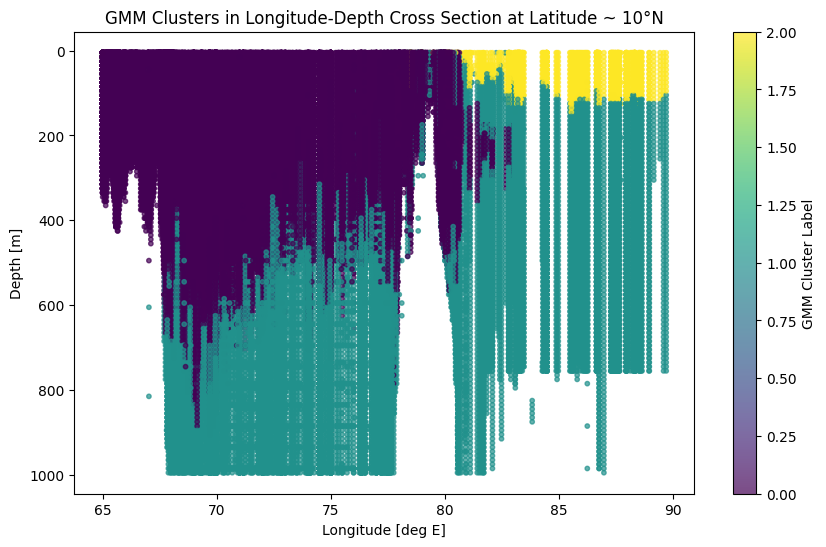

In [22]:
# Plot cross section for specific longitude slice
lat = 10
cross_sec_lon(lat, tol=0.5)

In [23]:
# Loss of information
z_mean, z_log_var = model.encode(torch.tensor(df_ST_scaled, dtype=torch.float32))
X_recon_vae = model.decode(z_mean)
X_recon_vae = X_recon_vae.detach().numpy()
mse = np.mean((df_ST_scaled - X_recon_vae) ** 2)
print(f'Mean Squared Error of VAE reconstruction: {mse}')

Mean Squared Error of VAE reconstruction: 0.12605065509366195
